# Mammograph preprocessing

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
import numpy as np
import matplotlib.patches as patches

This notebook demonstrates the various forms of preprocessing done to trained models.

## Mammography

A mammography consists of a side-view (MLO) and top-view (CC) image.

Let's view an example of a Mammography pair from CBIS-DDSM

In [21]:
IMG_OUT_DIR = Path("./output")
IMG_OUT_DIR.mkdir(exist_ok=True)

JPEG_ROOT = Path("../datasets/cbis-ddsm-breast-cancer-image-dataset/jpeg")

In [22]:
def get_img_id_from_dcm_file(path: Path):
    return str(path).split("/")[1]

def get_jpg_path(img_file_path: str):
    return JPEG_ROOT / img_file_path.replace("CBIS-DDSM/jpeg/", "")

def get_img_path(img_path):
    img_file = get_img_id_from_dcm_file(img_path)
    dicom_row = dicom_info_df[dicom_info_df.StudyInstanceUID == img_file].iloc[0]
    return get_jpg_path(dicom_row.image_path)

def get_patient_img(image_file_path):
    return Image.open(get_img_path(image_file_path))


def show_img_grid(cc_img, mlo_img):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(cc_img, cmap='gray')
    axes[0].set_title('Craniocaudal (CC)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Top-down view', fontsize=10, style='italic')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(mlo_img, cmap='gray')
    axes[1].set_title('Mediolateral Oblique (MLO)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Angled side view', fontsize=10, style='italic')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.savefig(IMG_OUT_DIR / 'mammogram_views.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
import pandas as pd

train_set_mass_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv")
dicom_info_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv")

In [24]:
train_set_mass_df[train_set_mass_df.patient_id == "P_02092"]

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,Mass-Training_P_02092_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...
1317,P_02092,2,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,Mass-Training_P_02092_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_02092_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_02092_LEFT_MLO_1/1.3.6.1.4.1.9...


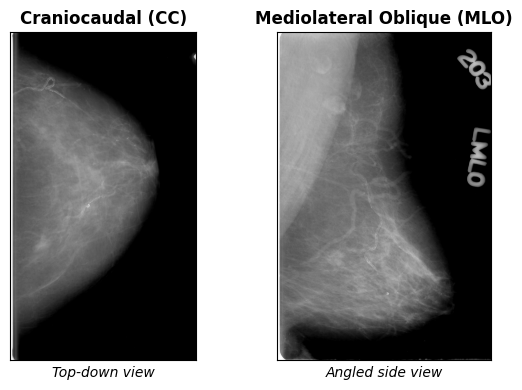

In [25]:
patient = train_set_mass_df[train_set_mass_df.patient_id == "P_02092"]

cc_img = get_patient_img(patient[patient["image view"] == "CC"].iloc[0]["image file path"])
mlo_img = get_patient_img(patient[patient["image view"] == "MLO"].iloc[0]["image file path"])
show_img_grid(cc_img, mlo_img)

## Region of interest cropping

To attempt to crop some of the area around the breast, I'll utilise some classical object detection approaches.

In [26]:
def show_img_grid(img_1, img_2):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(img_1, cmap='gray')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(img_2, cmap='gray')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

In [27]:
sample_img = np.array(cc_img.convert('L'))

### Gaussian Blur

A 5×5 Gaussian blur smooths out high-frequency noise while preserving the overall structure. This prevents small noise pixels from creating spurious regions during thresholding.

In [28]:
blurred_img = cv2.GaussianBlur(sample_img, (5, 5), 0)

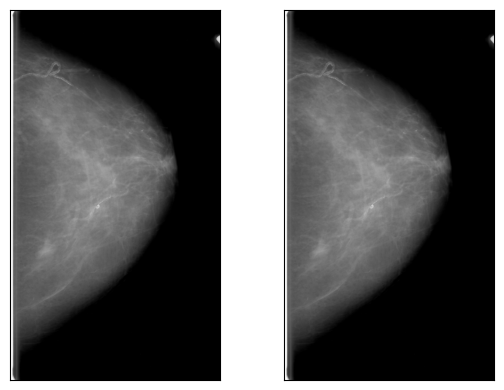

In [29]:
show_img_grid(sample_img, blurred_img)

### Otsu's Thresholding

Otsu's method automatically determines the optimal threshold value by minimising intra-class variance (or equivalently, maximising inter-class variance) between foreground and background pixels. This is ideal for separating the breast tissue from the dark background without manual threshold tuning.

In [30]:
_, breast_mask = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

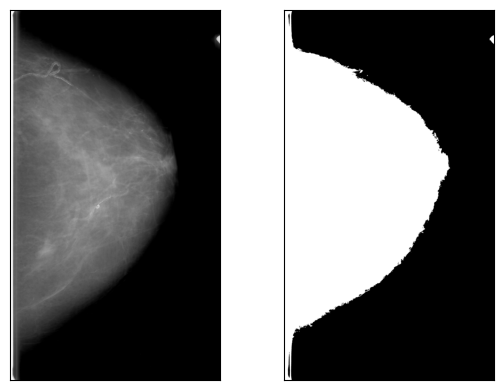

In [31]:
show_img_grid(blurred_img, breast_mask)

### Morphological Transformations

Morphological operations refine the binary mask by removing noise and filling gaps:

- **Opening** (erosion followed by dilation): Removes small bright spots/noise outside the breast region
- **Closing** (dilation followed by erosion): Fills small holes within the breast region

The 100×100 kernel size is chosen to handle the large scale of mammogram images (typically 3000-5000 pixels). Multiple iterations of closing ensure continuous breast boundaries.

In [32]:
breast_mask.shape

(5236, 2971)

In [33]:
def apply_morphological_transforms(
    thresh_frame, iterations: int = 2
):
    kernel = np.ones((100, 100), np.uint8)
    opened_mask = cv2.morphologyEx(thresh_frame, cv2.MORPH_OPEN, kernel)
    closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    return closed_mask

In [34]:
morph_img = apply_morphological_transforms(breast_mask)

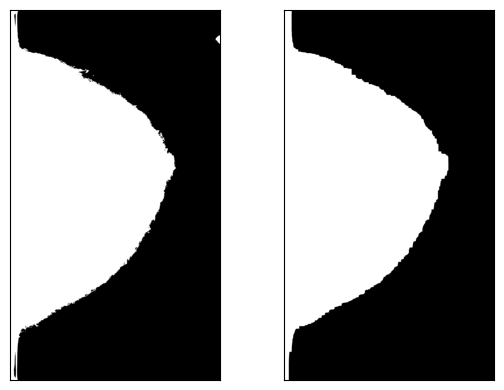

In [35]:
show_img_grid(breast_mask, morph_img)

Now we can find countours, and use the max contour as the overall bounding box.

In [36]:
def get_contours_from_mask(mask):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    return (x, y, w, h)

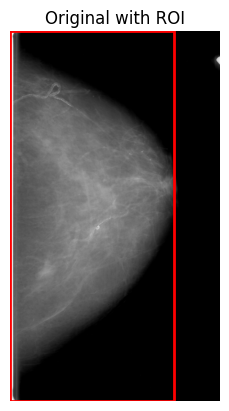

In [37]:
x, y, w, h = get_contours_from_mask(morph_img)

plt.imshow(sample_img, cmap='gray')
ax = plt.gca()

rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.title('Original with ROI')
plt.axis('off')
plt.show()

Combine all that into a function.

In [38]:
def crop_coords(img):
    """Get bounding box coordinates for the breast ROI after thresholding pipeline."""
    sample_img = np.array(img.convert('L'))
    blur = cv2.GaussianBlur(sample_img, (5, 5), 0)
    _, breast_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    morph_img = apply_morphological_transforms(breast_mask)
    return get_contours_from_mask(morph_img)

(-0.5, 2662.5, 5340.5, -0.5)

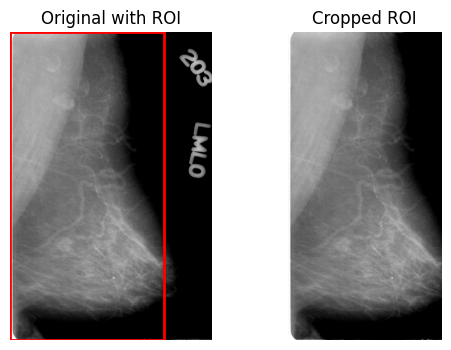

In [39]:
x, y, w, h = crop_coords(mlo_img)
sample_img = np.array(mlo_img.convert('L'))

# Display original with bounding box
fig, axes = plt.subplots(1, 2, figsize=(6, 4))

axes[0].imshow(sample_img, cmap='gray')
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original with ROI')
axes[0].axis('off')

# Display cropped ROI
img_cropped = sample_img[y:y+h, x:x+w]
axes[1].imshow(img_cropped, cmap='gray')
axes[1].set_title('Cropped ROI')
axes[1].axis('off')

## Truncation Normalisation

**Truncation normalisation** is a robust technique for handling intensity variations in medical images:

1. **Percentile-based clipping**: Rather than using the raw min/max values (which may be outliers), we use the 5th and 99th percentiles. This removes extreme values caused by artifacts, labels, or scanner noise.

2. **Min-max scaling**: After clipping, pixel values are linearly scaled to the [0, 1] range. This standardises the intensity distribution across different images and scanners.

**Why use truncation normalisation for mammography?**
- Different mammography machines produce varying intensity ranges
- Annotation markers or artifacts can create extreme pixel values
- Percentile-based clipping is more robust than z-score normalisation for images with non-Gaussian distributions
- The 5th/99th percentiles balance outlier removal with preserving diagnostic information

In [40]:
def truncation_normalisation(img):
    """
    Clip and normalize pixels in the breast ROI.
    Uses 5th and 99th percentiles to handle outliers.

    @img : numpy array image
    return: numpy array of the normalized image (values 0-1)
    """
    Pmin = np.percentile(img[img != 0], 5)
    Pmax = np.percentile(img[img != 0], 99)
    truncated = np.clip(img, Pmin, Pmax)
    normalized = (truncated - Pmin) / (Pmax - Pmin)
    normalized[img == 0] = 0
    return normalized

In [41]:
trunc_img = truncation_normalisation(img_cropped)

We show a histogram of pixel values side-by-side.

In [42]:
img_cropped

array([[255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0],
       ...,
       [255, 255, 255, ...,  66,  69,  72],
       [255, 255, 255, ...,  69,  72,  75],
       [255, 255, 255, ...,  72,  75,  79]], dtype=uint8)

In [43]:
trunc_img

array([[1.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [1.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [1.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.17467249, 0.18777293,
        0.20087336],
       [1.        , 1.        , 1.        , ..., 0.18777293, 0.20087336,
        0.2139738 ],
       [1.        , 1.        , 1.        , ..., 0.20087336, 0.2139738 ,
        0.23144105]])

## Pixel Distribution Before and After Normalisation

The truncation normalisation clips extreme pixel values and scales the image to a 0-1 range.
This helps reduce the impact of scanner variations and outlier pixels.

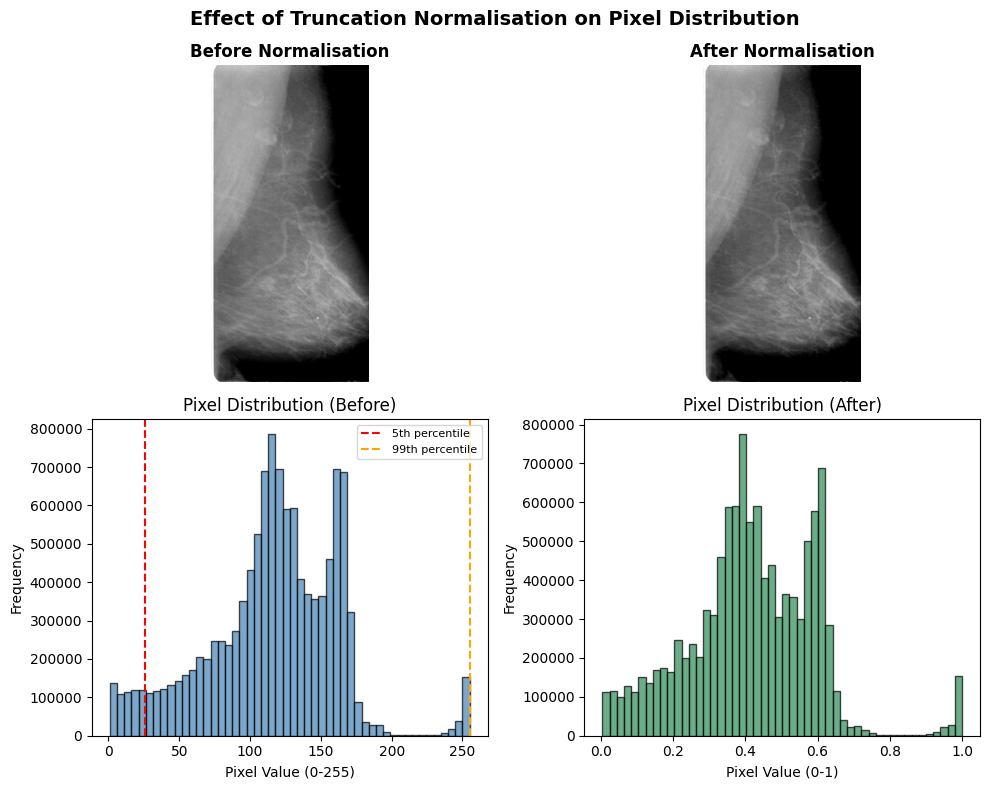

Before: min=1, max=255, mean=115.6, std=45.9
After:  min=0.004, max=1.000, mean=0.415, std=0.176


In [44]:
# Create figure with images and histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Before normalisation - image
axes[0, 0].imshow(img_cropped, cmap='gray')
axes[0, 0].set_title('Before Normalisation', fontweight='bold')
axes[0, 0].axis('off')

# Before normalisation - histogram
# Exclude background (0) pixels for cleaner histogram
pixels_before = img_cropped[img_cropped > 0].flatten()
axes[1, 0].hist(pixels_before, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Pixel Value (0-255)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Pixel Distribution (Before)')
axes[1, 0].axvline(x=np.percentile(pixels_before, 5), color='red', linestyle='--', label='5th percentile')
axes[1, 0].axvline(x=np.percentile(pixels_before, 99), color='orange', linestyle='--', label='99th percentile')
axes[1, 0].legend(fontsize=8)

# After normalisation - image
axes[0, 1].imshow(trunc_img, cmap='gray')
axes[0, 1].set_title('After Normalisation', fontweight='bold')
axes[0, 1].axis('off')

# After normalisation - histogram
pixels_after = trunc_img[trunc_img > 0].flatten()
axes[1, 1].hist(pixels_after, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Pixel Value (0-1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Pixel Distribution (After)')

plt.suptitle('Effect of Truncation Normalisation on Pixel Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_OUT_DIR / 'normalisation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"Before: min={pixels_before.min()}, max={pixels_before.max()}, mean={pixels_before.mean():.1f}, std={pixels_before.std():.1f}")
print(f"After:  min={pixels_after.min():.3f}, max={pixels_after.max():.3f}, mean={pixels_after.mean():.3f}, std={pixels_after.std():.3f}")

(-0.5, 2662.5, 5340.5, -0.5)

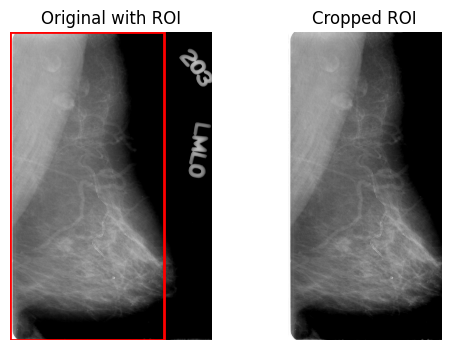

In [45]:
# Display original with bounding box
fig, axes = plt.subplots(1, 2, figsize=(6, 4))

axes[0].imshow(sample_img, cmap='gray')
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original with ROI')
axes[0].axis('off')

# Display cropped ROI
img_cropped = sample_img[y:y+h, x:x+w]
axes[1].imshow(trunc_img, cmap='gray')
axes[1].set_title('Cropped ROI')
axes[1].axis('off')

## Contrast Limited Adaptive Histogram Equalisation (CLAHE)

**CLAHE** is an advanced contrast enhancement technique that improves upon standard histogram equalisation:

1. **Adaptive**: Instead of computing a single histogram for the entire image, CLAHE divides the image into small tiles (default 8×8) and equalises each tile independently. This preserves local contrast details.

2. **Contrast Limited**: Standard adaptive histogram equalisation can over-amplify noise in homogeneous regions. CLAHE addresses this by clipping the histogram at a specified limit (`clipLimit`) before computing the cumulative distribution function. Excess pixels are redistributed uniformly across the histogram.

**Why use CLAHE for mammography?**
- Mammograms often have subtle tissue density variations that are diagnostically important
- CLAHE enhances local contrast, making calcifications and masses more visible
- The clip limit prevents noise amplification in uniform breast tissue regions
- Different clip limits (1.0, 2.0) capture different levels of detail, which we combine into RGB channels

In [46]:
def clahe(img, clip):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for image enhancement.

    @img : numpy array image (values 0-1)
    @clip : float, clip limit for CLAHE algorithm
    return: numpy array of the enhanced image (uint8)
    """
    clahe_obj = cv2.createCLAHE(clipLimit=clip)
    cl = clahe_obj.apply(np.array(img * 255, dtype=np.uint8))
    return cl

In [48]:
def preprocess_mammogram(img, target_size=512):
    """
    Full preprocessing pipeline for a mammogram image.
    1. Crop to ROI bounding box
    2. Normalize using truncation normalization
    3. Enhance contrast with CLAHE at multiple clip levels
    4. Merge into 3-channel image
    5. Resize to target size

    @img : numpy array image (grayscale)
    @target_size : int, target image size (square)
    return: numpy array of preprocessed image (3-channel, uint8)
    """
    # Crop to ROI
    x, y, w, h = crop_coords(img)
    sample_img = np.array(img.convert('L'))
    img_cropped = sample_img[y:y+h, x:x+w]

    # Normalize
    img_normalized = truncation_normalisation(img_cropped)

    # Enhance contrast with different CLAHE clip limits
    cl1 = clahe(img_normalized, 1.0)
    cl2 = clahe(img_normalized, 2.0)

    # Merge into 3-channel image (original normalized, CLAHE 1.0, CLAHE 2.0)
    img_final = cv2.merge((np.array(img_normalized * 255, dtype=np.uint8), cl1, cl2))

    # Resize to target size
    img_final = cv2.resize(img_final, (target_size, target_size))

    return img_final

### Full Pipeline & 3-Channel Output

The complete preprocessing pipeline combines all steps and outputs a 3-channel image:

- **Channel 1 (R)**: Original normalised image - preserves raw tissue intensity
- **Channel 2 (G)**: CLAHE with clip=1.0 - subtle contrast enhancement
- **Channel 3 (B)**: CLAHE with clip=2.0 - stronger contrast enhancement

This multi-channel approach allows the model to learn from different representations of the same image simultaneously, similar to how RGB channels capture different aspects of colour images. Each channel emphasises different features that may be relevant for classification.

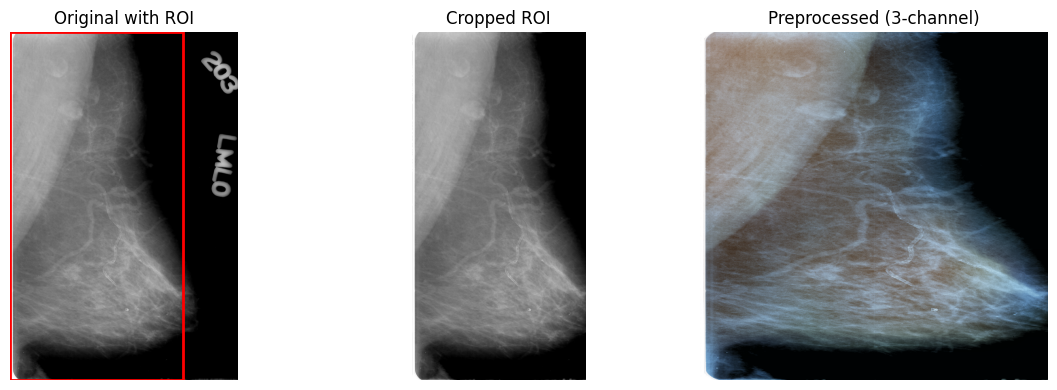

In [49]:
# Get ROI bounding box
x, y, w, h = crop_coords(mlo_img)

# Load a sample image
sample_img = np.array(mlo_img.convert('L'))

# Display original with bounding box
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_img, cmap='gray')
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original with ROI')
axes[0].axis('off')

# Display cropped ROI
img_cropped = sample_img[y:y+h, x:x+w]
axes[1].imshow(img_cropped, cmap='gray')
axes[1].set_title('Cropped ROI')
axes[1].axis('off')

# Display final preprocessed image
img_final = preprocess_mammogram(mlo_img)
axes[2].imshow(img_final)
axes[2].set_title('Preprocessed (3-channel)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Data Augmentation

Data augmentation is essential for training robust ML models on medical images,
especially with limited datasets. I use [Albumentations](https://albumentations.ai/)
for efficient, composable augmentations that preserve diagnostic relevance.

In [50]:
import albumentations as A

train_transform = A.Compose([
    # Crops
    A.RandomSizedCrop(min_max_height=(256, 480), size=(512, 512), p=0.4),

    # Flips
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # Downscale - simulates lower resolution acquisitions
    A.OneOf([
        A.Downscale(scale_range=(0.75, 0.95), interpolation_pair={'downscale': cv2.INTER_AREA, 'upscale': cv2.INTER_LINEAR}, p=0.1),
        A.Downscale(scale_range=(0.75, 0.95), interpolation_pair={'downscale': cv2.INTER_AREA, 'upscale': cv2.INTER_LANCZOS4}, p=0.1),
        A.Downscale(scale_range=(0.75, 0.95), interpolation_pair={'downscale': cv2.INTER_LINEAR, 'upscale': cv2.INTER_LINEAR}, p=0.8),
    ], p=0.125),

    # Contrast - simulates exposure variations
    A.OneOf([
        A.RandomToneCurve(scale=0.3, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.2), contrast_limit=(-0.4, 0.5),
        brightness_by_max=True, p=0.5)
    ], p=0.5),

    # Geometric - simulates positioning variations
    A.OneOf([
        A.Affine(
            scale=(0.85, 1.15), rotate=(-30, 30),
            translate_percent={'x': (-0.1, 0.1), 'y': (-0.2, 0.2)},
            border_mode=cv2.BORDER_CONSTANT,
            p=0.6
        ),
        A.ElasticTransform(
            alpha=1, sigma=20, interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT, approximate=False, p=0.2
        ),
        A.GridDistortion(
            num_steps=5, distort_limit=0.3, interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT, normalized=True, p=0.2
        ),
    ], p=0.5),
], p=0.9)

/Users/lex/code/uol/cm3070-final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Augmentation Demonstration

Below we visualise the augmentation pipeline applied to a preprocessed mammogram.

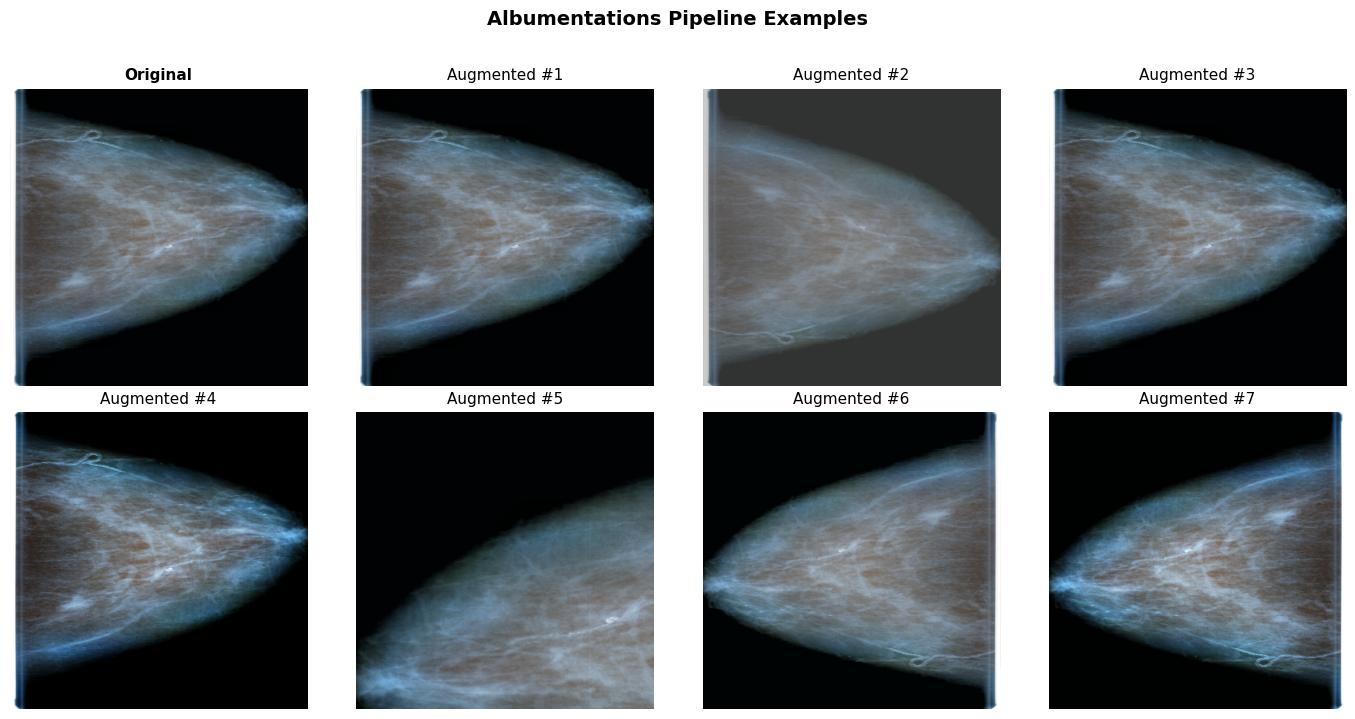

In [51]:
import random

# Use the preprocessed CC image
img_preprocessed = preprocess_mammogram(cc_img)
sample_img = np.array(cc_img.convert('L'))

# Show multiple random augmentations
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

axes[0].imshow(img_preprocessed)
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].axis('off')

random.seed(42)
np.random.seed(42)

for i, ax in enumerate(axes[1:], 1):
    augmented = train_transform(image=img_preprocessed)['image']
    ax.imshow(augmented)
    ax.set_title(f'Augmented #{i}', fontsize=11)
    ax.axis('off')

plt.suptitle('Albumentations Pipeline Examples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG_OUT_DIR / 'augmentations.png', dpi=150, bbox_inches='tight')
plt.show()